In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Show first rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Dataset size
df.shape

(1338, 7)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


لا يوجد أي قيمة فارغة في الداتا ست

In [ ]:
df[df.duplicated()]
#len(df[df.duplicated()])

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()
len(df[df.duplicated()])

0

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

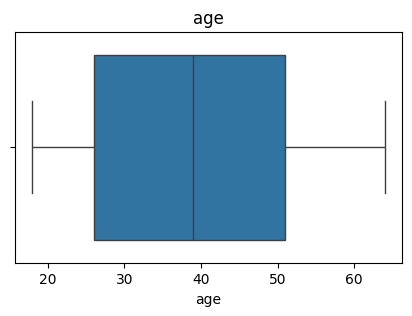

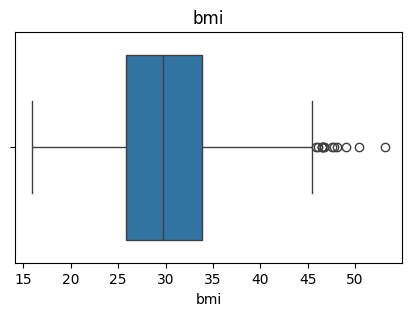

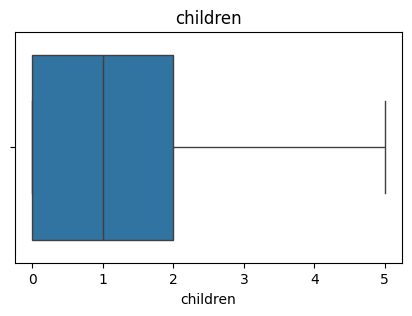

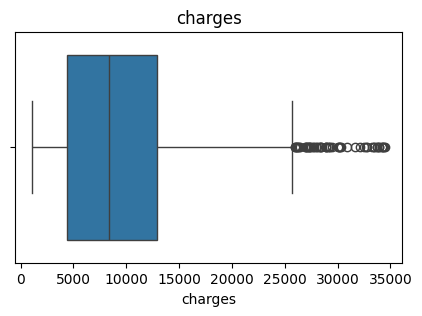

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

تم اكتشاف قيم شاذة في متغيري BMI و Charges باستخدام Boxplot. وبما أن هذه القيم تمثل بيانات حقيقية وليست أخطاء إدخال، فقد تم الإبقاء عليها وعدم حذفها.

الرسمة الأولى: توزيع التكاليف الطبية

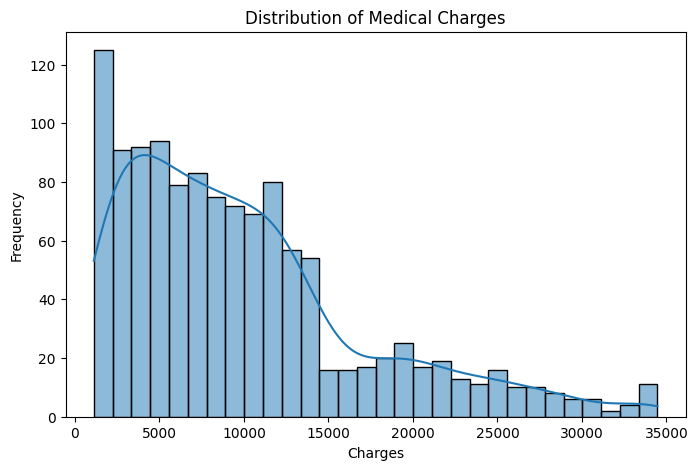

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

يوضح الرسم توزيع التكاليف الطبية. نلاحظ أن معظم القيم تتركز في التكاليف المنخفضة إلى المتوسطة، بينما يوجد عدد قليل من الحالات ذات التكاليف المرتفعة.

الرسمة الثاني: العلاقة بين BMI و Charges

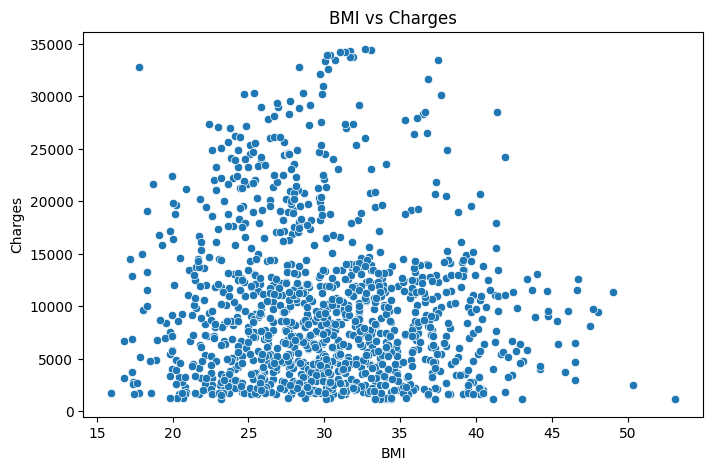

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

يظهر الرسم وجود علاقة موجبة بين BMI والتكاليف الطبية، حيث تميل التكاليف إلى الارتفاع مع زيادة قيمة BMI.

ثأثير الدخان

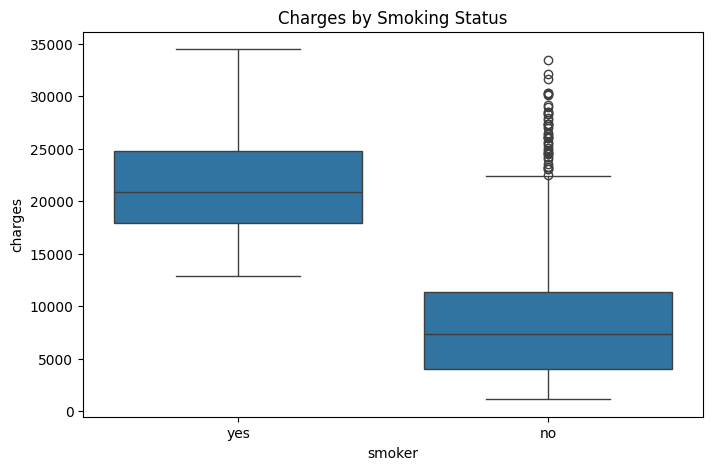

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

التدخين من أكثر العوامل تأثيراً على قيمة charges، حيث أن المدخنين يدفعون تكاليف أعلى.

Feature Engineering

In [ ]:
#تحويل المتغيرات النصية لرقمية
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
#فصل المتغيرات إلى عمود الهدف وباقي الأعمدة الاخر
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

تقسيم البيانات

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=10
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 4479.25382600532
R²: 0.6264191534440331


تطبيق Regularization (Ridge)

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R²:", r2_ridge)

Ridge RMSE: 4478.856251922033
Ridge R²: 0.6264854678244454


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    ridge,
    X_scaled,
    y,
    cv=kfold,
    scoring='r2'
)

print("Cross Validation Scores:")
print(scores)

print("Average R²:", scores.mean())

Cross Validation Scores:
[0.57479228 0.65836968 0.59687001 0.59117798 0.56768599]
Average R²: 0.597779187256623


In [ ]:
print("Linear Regression R²:", r2)
print("Linear Regression RMSE:", rmse)

print("Ridge Regression R²:", r2_ridge)
print("Ridge Regression RMSE:", rmse_ridge)

print("Cross Validation Mean R²:", scores.mean())

Linear Regression R²: 0.6264191534440331
Linear Regression RMSE: 4479.25382600532
Ridge Regression R²: 0.6264854678244454
Ridge Regression RMSE: 4478.856251922033
Cross Validation Mean R²: 0.597779187256623


تم تدريب نموذج Linear Regression للتنبؤ بقيم charges، ثم تم تطبيق Ridge Regression لتقليل احتمالية الـ Overfitting. حقق نموذج Linear Regression قيمة R² تساوي 0.6264 و RMSE يساوي 4479.25. أما نموذج Ridge Regression فقد حقق قيمة R² تساوي 0.6265 و RMSE يساوي 4478.86، مما يشير إلى تحسن طفيف في الأداء. كما تم استخدام K-Fold Cross Validation بعدد 5 طيات، وبلغ متوسط R² حوالي 0.598، مما يدل على استقرار مقبول للنموذج وقدرته على التعميم على بيانات جديدة.